In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sim_wrapper.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [2]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('omega_0', 9e9*2*pi)
sim.add_param('omega_d1', 9e9*2*pi)
sim.add_param('omega_phi', 1e9*2*pi)
sim.add_param('omega_demod', 10e9*2*pi, is_excitation=True)
sim.add_param('sqrtkappa', np.sqrt(1e9*2*pi))
sim.add_param('g', 1e9*2*pi)
sim.add_paramsweep('logAs', -5, 5, 100)
sim.add_param('epsilon', 1e-3)
sim.add_param('phi', 3)

sim.add_EOM('bin', '10**logAs * omega_d1*exp(-1j*(omega_d1*t + phi))')  # intput output theory
sim.add_EOM('a', '-1j*omega_0*a -1j*g*(conjugate(a)+a)**3 - (sqrtkappa**2/2)*a - sqrtkappa*bin')
sim.set_solve_type('decimate')

sim.specify_time(20, 1000, d_factor=10)

sim.validate()

Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


(5000000000.0, 15000000000.0)

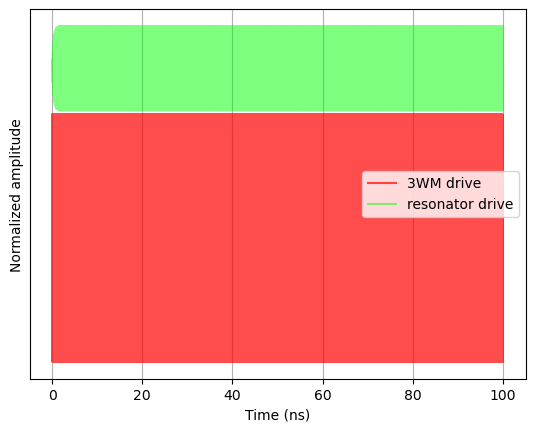

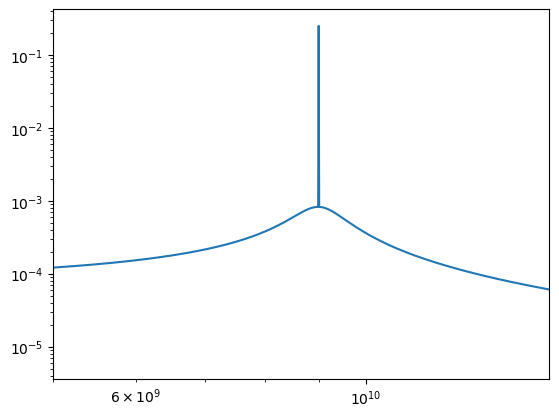

In [3]:
sim.param_dict_nosweep['logAs'] = 0

sim.param_dict_nosweep['phi'] = 0.7

x, t = sim.quick_trace()


plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='3WM drive')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='resonator drive')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.yticks([])
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[2, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())
plt.xlim([5e9, 15e9])

In [4]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|██████████████████████████████████████████████████████████████████████████| 20000/20000 [00:09<00:00, 2196.44it/s]

 
...finished GPU solve!


In [5]:
np.shape(I)

(4, 100, 100)

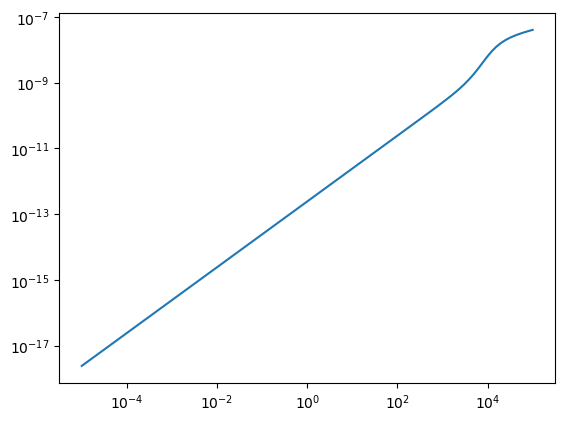

In [6]:
plt.loglog(10**sim.paramsweep_dict['logAs'],I[2,:,-1])